# RFM Customer Segmentation and KPI Analysis
## Objective
The goal of this project is to analyze customer purchasing behavior and segment customers using the RFM (Recency, Frequency, Monetary)
## Business value
Customer segmentation helps businesses:
- Improve customer retention
- Target marketing campaigns effectively
- Increase revenue through personalization


In [1]:
# Import core libraries for data analysis
import pandas as pd
import numpy as np
import datetime as dt
import os

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings for better readability
pd.set_option('display.max_columns', None)

print(os.getcwd())


C:\Users\ASUS


In [2]:
# Load dataset
df = pd.read_csv('SuperStoreOrders.csv')

# Preview data
df.head()

,order_id,order_date,ship_date,ship_mode,customer_name,segment,state,country,market,region,product_id,category,sub_category,product_name,sales,quantity,discount,profit,shipping_cost,order_priority,year
0,AG-2011-2040,1/1/2011,6/1/2011,Standard Class,Toby Braunhardt,Consumer,Constantine,Algeria,Africa,Africa,OFF-TEN-10000025,Office Supplies,Storage,"Tenex Lockers, Blue",408,2,0.0,106.140,35.46,Medium,2011
1,IN-2011-47883,1/1/2011,8/1/2011,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,OFF-SU-10000618,Office Supplies,Supplies,"Acme Trimmer, High Speed",120,3,0.1,36.036,9.72,Medium,2011
2,HU-2011-1220,1/1/2011,5/1/2011,Second Class,Annie Thurman,Consumer,Budapest,Hungary,EMEA,EMEA,OFF-TEN-10001585,Office Supplies,Storage,"Tenex Box, Single Width",66,4,0.0,29.640,8.17,High,2011
3,IT-2011-3647632,1/1/2011,5/1/2011,Second Class,Eugene Moren,Home Office,Stockholm,Sweden,EU,North,OFF-PA-10001492,Office Supplies,Paper,"Enermax Note Cards, Premium",45,3,0.5,-26.055,4.82,High,2011
4,IN-2011-47883,1/1/2011,8/1/2011,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,FUR-FU-10003447,Furniture,Furnishings,"Eldon Light Bulb, Duo Pack",114,5,0.1,37.770,4.70,Medium,2011


## Data Understanding
We first explore the dataset structure, missing values and data types.

In [3]:
# Check data info
df.shape
df.columns
df.info()

# Check missing values
df.isnull().sum()

# Basic statistics
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   order_id        51290 non-null  object 
 1   order_date      51290 non-null  object 
 2   ship_date       51290 non-null  object 
 3   ship_mode       51290 non-null  object 
 4   customer_name   51290 non-null  object 
 5   segment         51290 non-null  object 
 6   state           51290 non-null  object 
 7   country         51290 non-null  object 
 8   market          51290 non-null  object 
 9   region          51290 non-null  object 
 10  product_id      51290 non-null  object 
 11  category        51290 non-null  object 
 12  sub_category    51290 non-null  object 
 13  product_name    51290 non-null  object 
 14  sales           51290 non-null  object 
 15  quantity        51290 non-null  int64  
 16  discount        51290 non-null  float64
 17  profit          51290 non-null 

,quantity,discount,profit,shipping_cost,year
count,51290.000000,51290.000000,51290.000000,51290.000000,51290.000000
mean,3.476545,0.142908,28.641740,26.375915,2012.777208
std,2.278766,0.212280,174.424113,57.296804,1.098931
min,1.000000,0.000000,-6599.978000,0.000000,2011.000000
25%,2.000000,0.000000,0.000000,2.610000,2012.000000
50%,3.000000,0.000000,9.240000,7.790000,2013.000000
75%,5.000000,0.200000,36.810000,24.450000,2014.000000
max,14.000000,0.850000,8399.976000,933.570000,2014.000000


In [4]:
# Convert order_date & ship_date to datetime format
df['order_date'] = pd.to_datetime(df['order_date'], format='mixed')
df['ship_date'] = pd.to_datetime(df['ship_date'], format='mixed')

In [5]:
# Create time-based features (year, month number, and month name) from order_date for aggregation and trend analysis
df['year'] = df['order_date'].dt.year
df['month'] = df['order_date'].dt.month
df['month_name'] = df['order_date'].dt.month_name()
    

## Business Questions
1. Which region generates the highest sales?
2. Which product category performs best?
3. What are the top states by revenue?
4. How does sales change over time?
5. Which product generates the most profit?

In [6]:
# Ensure 'sales' is numeric and calculate total sales
df['sales'] = pd.to_numeric(df['sales'], errors='coerce')
df['sales'].sum()

np.float64(7835128.0)

In [7]:
# Aggregate total sales by region and sort in descending order to identify top-performing regions
# Answering Business Question 1
df.groupby('region')['sales'].sum().sort_values(ascending=False)

region
Central           1806638.0
South             1031101.0
North              790546.0
Oceania            625382.0
EMEA               575562.0
Africa             538115.0
Southeast Asia     532172.0
North Asia         453686.0
West               424173.0
Central Asia       389506.0
East               366492.0
Caribbean          251441.0
Canada              50314.0
Name: sales, dtype: float64

In [8]:
# Aggregate total sales by product category and rank them by performance
# Answering Business Question 2
df.groupby('category')['sales'].sum().sort_values(ascending=False)

category
Office Supplies    2790258.0
Technology         2638265.0
Furniture          2406605.0
Name: sales, dtype: float64

In [9]:
# Total sales by state(ranked)
# Answering Business Question 3
df.groupby('state')['sales'].sum().sort_values(ascending=False)

state
England            273710.0
California         270615.0
Ile-de-France      188108.0
New York           153366.0
New South Wales    145380.0
                     ...   
Khorezm                 0.0
Shumen                  0.0
Sikasso                 0.0
Wyoming                 0.0
Elbasan                 0.0
Name: sales, Length: 1094, dtype: float64

In [10]:
# Analyze revenue vs profit by category to identify high-performing and high-margin segments
df.groupby('category')[['sales','profit']].sum()

,sales,profit
category,,
Furniture,2406605.0,286782.25380
Office Supplies,2790258.0,518473.83430
Technology,2638265.0,663778.73318


In [11]:
# Identify top products based on total profit
# Answering Business Question 5
top_products_profit = df.groupby('product_name')['profit'].sum().sort_values(ascending=False).head(5)
top_products_profit

product_name
Canon imageCLASS 2200 Advanced Copier    25199.9280
Cisco Smart Phone, Full Size             17238.5206
Motorola Smart Phone, Full Size          17027.1130
Hoover Stove, Red                        11807.9690
Sauder Classic Bookcase, Traditional     10672.0730
Name: profit, dtype: float64

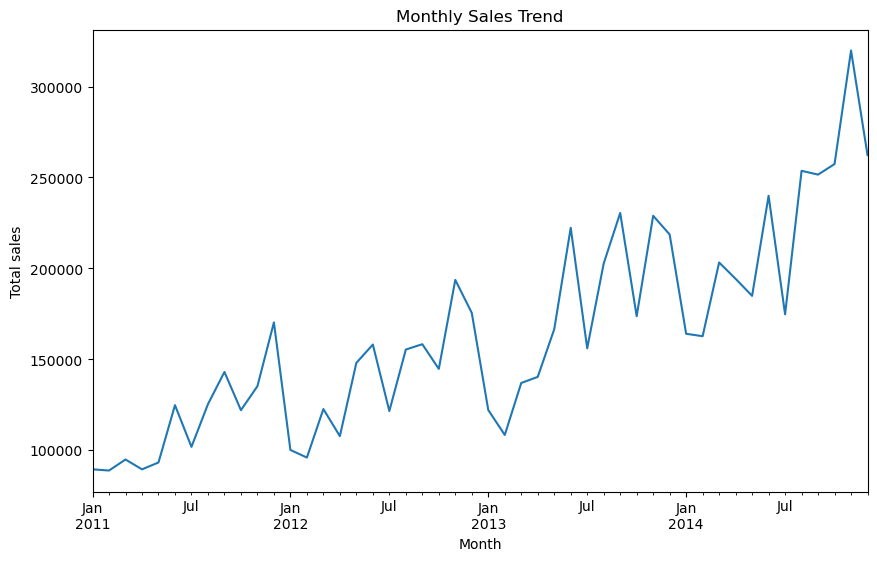

In [12]:
# Analyze monthly sales trend by aggregating revenue over time and plotting for pattern detection
# Answering Business Question 4
monthly_sales = df.groupby(df['order_date'].dt.to_period('M'))['sales'].sum()
monthly_sales.plot(figsize=(10,6))
plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Total sales')
plt.show()

# Insight
Sales exhibit significant monthly fluctuations with a clear seasonal pattern, peaking consistently in the fourth quarter of each year.

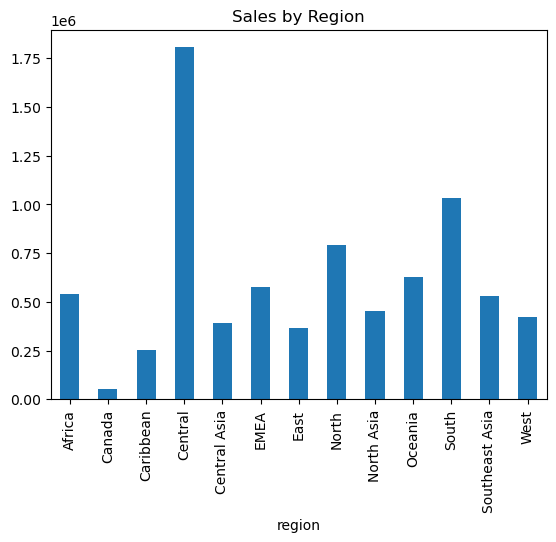

In [13]:
# Visualize total sales by region to compare regional performance
df.groupby('region')['sales'].sum().plot(kind='bar')

# Add chart title
plt.title('Sales by Region')
plt.show()

# Insight
Sales are highly concentrated in a few regions, with Central leading significantly, indicating strong market dominance in that area.

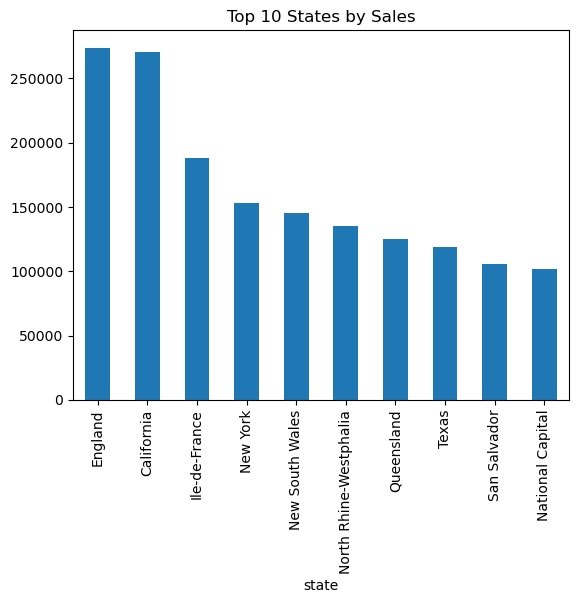

In [14]:
# Visualize top 10 states by total sales to highlight key revenue-driving locations
df.groupby('state')['sales'].sum().sort_values(ascending=False).head(10).plot(kind='bar')
plt.title('Top 10 States by Sales')
plt.show()

# Insight
Sales are concentrated in a few key regions and states, indicating potential dependency on specific markets.

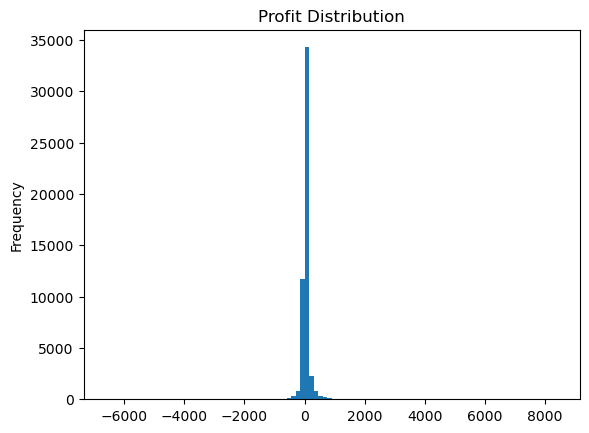

In [15]:
# Analyze the distribution profit to understand variabilty, skewness and presence of outliers
df['profit'].plot(kind='hist', bins=100)
plt.title('Profit Distribution')
plt.show()

## Insight
Profit distribution is right-skewed, with most transactions generating small positive profits, while a small number extreme values (both losses and high gains) exist. This indicates variability in profitability and potential inefficiencies in pricing or cost structure.

In [16]:
# Find loss-making transactions
loss_df = df[df['profit'] < 0]


## Key Insights
- The Central region generates the highest total sales, indicating strong regional performance and market dominance.
- Technology is the best performing category overal due to its superior contribution to the company's bottom line.
- Sales are highly concentrated in a few key markets, with England and California leading revenue generation.
- The businness showes a clear upward trend over time, with noticeable seasonality and significant sales spikes toward the end of the year that require more inventory and staff compared to the slower first months of the year.

In [17]:
# Calculate key business metrics (KPIs)
total_sales = df['sales'].sum()
total_profit = df['profit'].sum()
total_orders = df['order_id'].nunique()
avg_order_value = total_sales / total_orders

# Calculate profit margin (efficiency metric)
profit_margin = total_profit/total_sales

In [18]:
# Display KPIs in a clean and readable format
print(f"Total sales: ${total_sales:,.0f}")
print(f"Total Profit: ${total_profit:,.0f}")
print(f"Total Order: {total_orders:,}")
print(f"Avg Order Value: ${avg_order_value:,.2f}")
print(f"Profit Margin: {profit_margin:.2%}")

Total sales: $7,835,128
Total Profit: $1,469,035
Total Order: 25,035
Avg Order Value: $312.97
Profit Margin: 18.75%


## Key KPIs
- **Total Sales:** $7,835,128
- **Total Profit:** $1,469,035
- **total Order:** 25,035
- **Average Order Value:** $312.96
- **Profit Margin:** 18.75%

## KPI Insights
- The business generated over $7.8M in total sales, indicating strong overal performance. 
- Total profit is approximately $1.46M, suggesting a solid but improvable margin.
- With over 25k orders, the company operate at a good scale.
- The average order value($313) indicates moderate customer spending.
- The profit margin highlights how efficiently the business converts revenue into profit.

In [19]:
# Analyze toatl sales and profit by product category to identify top-performing segments
df.groupby('category')[['sales', 'profit']].sum().sort_values(by='sales', ascending=False)

,sales,profit
category,,
Office Supplies,2790258.0,518473.83430
Technology,2638265.0,663778.73318
Furniture,2406605.0,286782.25380


In [20]:
# Eveluate the relationship between discount levels an profitabilty to identify how discounts affect average profit
df.groupby('discount')['profit'].mean()

discount
0.000      61.039514
0.002     125.762649
0.070     140.990022
0.100      64.071216
0.150      50.602409
0.170      38.317107
0.200      23.552594
0.202     -14.518847
0.250       4.043371
0.270      -4.317213
0.300     -57.899557
0.320     -88.560656
0.350    -116.144693
0.370     -78.462191
0.400     -45.246603
0.402    -109.908138
0.450     -41.610973
0.470     -42.982420
0.500     -97.140158
0.550    -315.067200
0.570    -526.129000
0.600     -81.732147
0.602    -213.279085
0.650    -365.997971
0.700    -104.339576
0.800    -122.203244
0.850   -1534.329000
Name: profit, dtype: float64

# Insight
There is a clear "break-even" point at a 20% discount. Any discount higher than this leads to an average net loss per sale.

## Recommendation
The sales team should be restricted from offering discount greater than 20% unless it is for clearing obsolete or damaged inventory.

In [21]:
# Identify top 10 products based on total sales
# Best selling items
df.groupby('product_name')['sales'].sum().sort_values(ascending=False).head(10)

product_name
Eldon File Cart, Single Width                         31319.0
Rogers File Cart, Single Width                        22645.0
Tenex File Cart, Single Width                         20778.0
Smead File Cart, Single Width                         20775.0
Office Star Executive Leather Armchair, Adjustable    19355.0
Fellowes Lockers, Industrial                          19172.0
Smead Lockers, Industrial                             18648.0
Hewlett Copy Machine, Color                           16849.0
Rogers Lockers, Blue                                  16494.0
Fellowes Lockers, Wire Frame                          16470.0
Name: sales, dtype: float64

In [22]:
# Identify top customer by sales
# High value clients
# Customer retention
df.groupby('customer_name')['sales'].sum().sort_values(ascending=False).head(10)

customer_name
Eric Murdock        19489.0
John Grady          19483.0
Maria Etezadi       18237.0
Theone Pippenger    17416.0
Dan Reichenbach     16705.0
Ben Ferrer          16661.0
Randy Bradley       16399.0
Mathew Reese        16125.0
Muhammed Yedwab     16091.0
Steven Ward         15984.0
Name: sales, dtype: float64

In [23]:
# Analyze average shipping cost by shipping mode
df.groupby('ship_mode')['shipping_cost'].mean()

ship_mode
First Class       41.053065
Same Day          42.937453
Second Class      30.469747
Standard Class    19.971755
Name: shipping_cost, dtype: float64

In [24]:
# Analyze distribution of shipping modes to understand customer preferences
df['ship_mode'].value_counts()

ship_mode
Standard Class    30775
Second Class      10309
First Class        7505
Same Day           2701
Name: count, dtype: int64

# Insight
The majority of customers prefer Standard Class shipping, indiacting cost sensitivity and an opportunity to optimize logistic expenses. 

## Business Recommendations

### 1. Optimize Discounting Strategy
- **Problem:** Discounts exceeding 20% lead to a negative average profit. Extreme discounts(80%+) are causing massive losses.
- **Insight:** High discount levels significantly reduce profitability.
- **Action:**
   - Implement a strict "Discount Cap" at 15-20% for standard sales.
   - Any discount above this threshold should require management approval.
   - Reserve extreme discounts for inventory clearance only.
---

### 2. Capitalize on High-Margin Categories
- **Problem:** Office supplies drive volume, but Technology generates the highest profit.
- **Insight:** Not all high-sales categories are equally profitable.
- **Action:**
   - Increase marketing investment in Technology.
   - Promote upselling of high-margin products.
   - Re-evaluate pricing in low-margin categories.
---

### 3. Manage Seasonality in Operations
- **Problem:** Sales consistently spike in Quarter 4 and dip in January/February.
- **Insight:** Strong seasonal demand pattern exists.
- **Action:**
   - Scale up inventory levels and staffing before peak periods (Q4).
   - Use slow periods (Q1) for training and operational improvements.
---

### 4. Reduce Loss-Making Transactions
- **problem:** Some orders generate negative profit.
- **Insight:** Inefficiencies exist in pricing, discounting, or shipping.
- **Action:**
  - Identify and eliminate consistently unprofitable products or regions.
  - Adjust pricing or shipping strategies.

# Customer Value Segmentation (RFM Analysis)
## Objective
To categorize our customer base into actionable segments to optimize marketing strategy.

In [25]:
# Filter out negative sales (returns)
df = df[df['sales'] > 0]
# Define the reference date as one day after the last purchase in dataset
# This serves as 'today' for calculating recency
reference_date = df['order_date'].max() + pd.Timedelta(days=1)

print(f"Minimum Order Date: {df['order_date'].min()}")
print(f"Maximum Order Date: {df['order_date'].max()}")
print(f"Reference Date for Recency: {reference_date}")

Minimum Order Date: 2011-01-01 00:00:00
Maximum Order Date: 2014-12-31 00:00:00
Reference Date for Recency: 2015-01-01 00:00:00


In [26]:
# Group by customer name and caculate by RFM metrics
rfm = df.groupby('customer_name').agg({
    'order_date': lambda x: (reference_date - x.max()).days, # Recency
    'order_id': 'count',
    # Frequency
    'sales': 'sum'
    # Monetary
})

rfm.columns = ['Recency','Frequency','Monetary']
# Display the first few rows of the RFM table
print(rfm.head())

                 Recency  Frequency  Monetary
customer_name                                
Aaron Bergman         17         82   13814.0
Aaron Hawkins         13         50    9171.0
Aaron Smayling        27         57    9675.0
Adam Bellavance       26         62    7469.0
Adam Hart             32         79   14637.0


In [27]:
# Create quintiles for RFM scoring 
# For Recency lower days = higher score (Smaller is better)
# For Frequency and Monetary higher count/sum = higher score (Higher is better)

rfm['R_score'] = pd.qcut(rfm['Recency'], 5, labels=[5,4,3,2,1])
rfm['F_score'] = pd.qcut(rfm['Frequency'], 5, labels=[1,2,3,4,5])
rfm['M_score'] = pd.qcut(rfm['Monetary'], 5, labels=[1,2,3,4,5])

# Combine scores into a single RFM string 
rfm['RFM_Score'] = rfm['R_score'].astype(str) + rfm['F_score'].astype(str) + rfm['M_score'].astype(str)

print(rfm.head())

                 Recency  Frequency  Monetary R_score F_score M_score  \
customer_name                                                           
Aaron Bergman         17         82   13814.0       3       5       5   
Aaron Hawkins         13         50    9171.0       4       1       3   
Aaron Smayling        27         57    9675.0       2       2       3   
Adam Bellavance       26         62    7469.0       2       3       1   
Adam Hart             32         79   14637.0       2       5       5   

                RFM_Score  
customer_name              
Aaron Bergman         355  
Aaron Hawkins         413  
Aaron Smayling        223  
Adam Bellavance       231  
Adam Hart             255  


In [28]:
# Function to assign segments based on RFM score
def segment_customer(row):
    # Champions: High score in all categories
    if row['R_score'] >= 4 and row['F_score'] >=4 and row['M_score'] >= 4:
        return "Champions"
    # Loyal customers: High Frequency
    elif row['F_score'] >= 4:
        return "Loyal Customers"
    # Potential Loyalists:Recent, but lower frequency
    elif row['R_score'] >= 4:
        return "Potential Loyalists"
    # At Risk: Low Recency; haven't bought in a while
    elif row['R_score'] <= 2:
        return "At Risk"
    else:
        return "others"

# Apply the segmentation logic
rfm['Segment'] = rfm.apply(segment_customer, axis=1)

# Display the final results
print(rfm[['Recency', 'Frequency', 'Monetary', 'Segment']].head())

                 Recency  Frequency  Monetary              Segment
customer_name                                                     
Aaron Bergman         17         82   13814.0      Loyal Customers
Aaron Hawkins         13         50    9171.0  Potential Loyalists
Aaron Smayling        27         57    9675.0              At Risk
Adam Bellavance       26         62    7469.0              At Risk
Adam Hart             32         79   14637.0      Loyal Customers


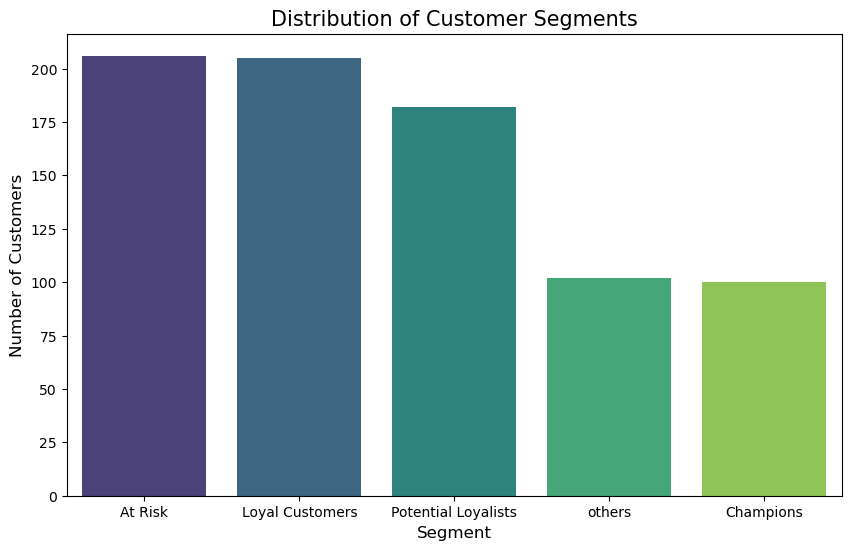

In [29]:
# Plotting the distribution of customer segments
plt.figure(figsize=(10,6))
segment_counts = rfm['Segment'].value_counts()
sns.barplot(x=segment_counts.index, y=segment_counts.values, hue=segment_counts.index, palette='viridis', legend=False)

plt.title('Distribution of Customer Segments', fontsize=15)
plt.xlabel('Segment', fontsize=12)
plt.ylabel('Number of Customers', fontsize=12)
plt.show()

## RFM Insights
- A large portion of customers fall into the "At Risk" and "Potential Loyalists" segments, indicating opportunities fro re-engagement and growth.
- Loyal Customers represent a strong core user base contributing to consistent revenue.
- Champions are relatively smaller but highly valuable, requiring retention-focused strategies.

### Key Findings & Strategic Recommendations

* **Champions (Top Tier):** These customers have the highest frequency and monetary values. 
    * *Action:* Implement an exclusive VIP loyalty programs, exclusive offers and early access to products to maintain their engagement and boost brand advocacy.
* **Loyal Customers:** Consistent buyers who form the backbone of our revenue.
    * *Action:* Use personalized product recommendations and loyalty rewards based on their purchase history to increase their average order value.
* **Potential Loyalists:** Recent customers with growth potential.
    * *Action:* Focus on engagement content and welcome campaigns to convert them into regular buyers.
* **At Risk:** Customers who haven't purchased in a while but previously had high engagement.
    * *Action:* Launch an immediate **win-back email campaign** with limited-time offers to re-engage them before they churn.

### Conclusion & Impact
This RFM model transforms raw transactional data into **actionable business intelligence**. By transitioning from 'one-size-fits-all' marketing to **segment-specific communication**, the business can:
- Significantly optimize marketing budget
- Reduce churn rates
- Maximize the Customer Lifetime Value (CLV)
- Improve Customer retention

This data-driven approach ensures that every marketing dollar is invested where it has the highest potential return.

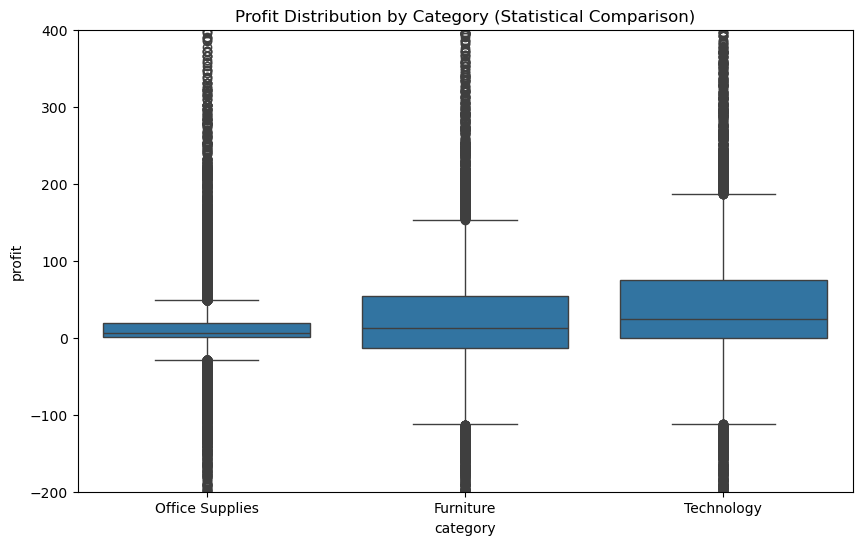

F-Statistic: 166.03
p-Value:0.0000
Result: Significant diffrenece found between categories (Reject Null Hypothesis(H0))


In [30]:
# Perform Anova test to check if profit differs significantly across categories

import scipy.stats as stats

# Extract profit for each category
tech_profit = df[df['category']=='Technology']['profit']
office_profit = df[df['category']=='Office Supplies']['profit']
furniture_profit = df[df['category']=='Furniture']['profit']

# Run Anova test
f_stat, p_value = stats.f_oneway(tech_profit, office_profit, furniture_profit)

# Visualization
plt.figure(figsize=(10,6))
sns.boxplot(x='category', y='profit', data=df)
plt.ylim(-200,400)
plt.title('Profit Distribution by Category (Statistical Comparison)')
plt.show()

print(f"F-Statistic: {f_stat:.2f}")
print(f"p-Value:{p_value:.4f}")

# Interpretation
if p_value < 0.05:
    print("Result: Significant diffrenece found between categories (Reject Null Hypothesis(H0))")
else: 
    print("Result: no significant difference found (Fail to reject Null Hypothesis(H0))")
    
    
    

## Statistical Insight (ANOVA Test)
- The ANOVA test shows a statistically significant difference in profit across produt categories (p < 0.05).
- Technology category demonstrates higher median profit and greater variability compared to others.
- Office supplies shows tighter distribution with lower margins.
- Furniture exhibits higher variability with frequent negative profits.

### Business Interpretation
The company should prioritize high-margin categories like Technology while optimizing pricing and cost structures in lower-perfroming categories such as Furniture.

## Statistical Validation & Logistics Optimization

To ensure that my insight were based on random fluctuations, I continiued high-level statistical testic and logistical cost analysis.

#### **1. ANOVA Test: Categorical Profitability Validation**
* **Finding:** The **P-value (0.0000)** and **F-statistic (166.03)** confirm a statistically significant difference in profit margins across categories.
*  **Insight:** We have a 99.9% confidence level that **Technology** is inherently more profitable than furniture and office supplies.
*  **Business Impact:** This justifies a strategic shift in marketing budget allocation toward high-margin tech products.
---
#### **2. Logistics and Shipping Cost Analysis**
*  **Standard Class Efficiency:** Although it accounts for the highest volume  (**30,755 orders**), it maintains the lowest average cost (**$19.97**).
*  **Premium Leakage:** **Same Day** shipping is **115% more expensive** than Standard Class but is used in less than 7% of total orders.
*  **Recommendations:** Since standard Class is the most stable and cost-effective, the business should maintain its current shipping mix while investing if "First Class" cost can be negotiated down to "second Class" levels (-30).


In [32]:
# Calculate profit margin per category after filtering
category_margin = df.groupby('category')[['sales', 'profit']].sum()
category_margin['profit_margin'] = category_margin['profit']/category_margin['sales']

category_margin

,sales,profit,profit_margin
category,,,
Furniture,2406605.0,97049.37790,0.040326
Office Supplies,2790258.0,350108.43450,0.125475
Technology,2638265.0,267573.47238,0.101420
